# Pooled spectrograms by stimulus orientation (45° vs 135°)

Same pooling as `image_spectra.ipynb` (every individual grating presentation, labelled by
its physical **orientation** — 45° or 135° — across the analysis conditions), but rendered
as **time-frequency spectrograms**: one heatmap per visual area, 45° beside 135°.

**Why a per-subject grand *average*, not a grandcat.** The reference spectrogram pipeline
(`grand_spectrogram.ipynb`) runs one `Spectrogram` over a `GrandConcatenation` of all
trials. That path is unusable here: the saved visual aligner's `num_times` is baked from
the full-trial epochs it was fit on (~6858 samples), and `GrandConcatenation` sizes its
accumulator to that and assumes every epoch is at least that long — but our per-stimulus
epochs are only ~0.5 s (~1375 samples), so it errors (`operands could not be broadcast
(6858,) (1375,)`). It would also try to hold every pooled trial's LFP in RAM at once
(orientation pools are far larger than the per-condition pools). Instead we compute a
`Spectrogram` **per subject** (channel-aligned first, so laminar channels match across
subjects), trial-average each (`erp`), and average those small TFRs across subjects. This
also weights subjects equally, which mitigates the 8-vs-6 orientation/role imbalance noted
in `image_spectra.ipynb`.

**Prerequisite:** run the epoching stage of `image_spectra.ipynb` first — it writes the
per-subject pools consumed here: `<subject_dir>/ori_45` and `<subject_dir>/ori_135`.

The dB baseline is the brief pre-onset window (epochs are short, so it is imperfect — the
preceding stimulus is adjacent); read the maps as relative time-frequency structure.
Requires the dataset at `/mnt/data/000253`.

**Alignment caveat:** the saved aligner uses global-k indexing (`AREA_COUNTER` advanced per
subject during alignment). Cache hits skip alignment, so do NOT mix cached and freshly
computed subjects in one run — recompute all (delete the `spectrogram_ori_*` caches or set
`FORCE_RECOMPUTE`) if in doubt. All-cached and all-fresh are both correct.

In [1]:
%cd ../..

/home/eli/AnacondaProjects/epych


In [2]:
%env DASK_LOGGING__DISTRIBUTED=CRITICAL
%env OMPI_MCA_btl_sm_backing_directory=/mnt/data/tmp_storage
%env SPYTMPDIR=/mnt/data/tmp_storage
%env SPYLOGLEVEL=CRITICAL
%env SPYPARLOGLEVEL=CRITICAL

env: DASK_LOGGING__DISTRIBUTED=CRITICAL
env: OMPI_MCA_btl_sm_backing_directory=/mnt/data/tmp_storage
env: SPYTMPDIR=/mnt/data/tmp_storage
env: SPYLOGLEVEL=CRITICAL
env: SPYPARLOGLEVEL=CRITICAL


In [3]:
import collections
import functools
import glob
import logging
import numpy as np
import os
import quantities as pq

import epych
from epych.statistics import alignment, spectrum

[striatum:104781] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.striatum.1000/jf.0/3395944448/shared_mem_cuda_pool.striatum could be created.
[striatum:104781] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 


In [4]:
%matplotlib inline

In [5]:
logging.basicConfig(level=logging.INFO)

## Configuration

In [6]:
ORIENTATIONS = [45, 135]
ORIENTATION_TITLES = {45: "45°", 135: "135°"}

DOWNSAMPLE = 4               # LFP decimation before the time-frequency transform
TIME_WINDOW = 0.150          # syncopy t_ftimwin (s): temporal vs frequency resolution
PRESTIM_BASELINE = (-0.1 * pq.second, 0.0 * pq.second)   # dB baseline, pre-onset
VMIN, VMAX = -3.25, 3.25     # spectrogram colour limits (dB)

# Single event: the stimulus onset every epoch is aligned to.
EVENTS = {"Stimulus onset": (0.0, "lightgreen")}

FORCE_RECOMPUTE = False

AREA_TITLES = {"VISal": "AL", "VISam": "AM", "VISl": "LM", "VISp": "V1", "VISpm": "PM", "VISrl": "RL"}
anatomical_areas = ['VISp', 'VISl', 'VISrl', 'VISal', 'VISpm', 'VISam']

In [7]:
NWB_SUBJECTS = glob.glob('/mnt/data/000253/sub-*/')

In [8]:
aligner = epych.statistics.alignment.AlignmentSummary.unpickle("/mnt/data/000253/visual_alignment")
AREA_COUNTER = collections.Counter()

## Per-subject spectrograms

`visual_align` selects visual channels, median-filters, and laminar-aligns each subject
(same as `image_spectra.ipynb`), so per-area channel counts match across subjects.

`aligned_area_signals` then returns ONE signal per area. This matters because some subjects
have two probes in the same area (e.g. `sub-621890` has probeD and probeE both in VISl —
the doubled-probe case). `Spectrogram.apply` asserts the *whole* channel frame matches
(unlike `PowerSpectrum`, which only checks `location`), so two same-area probes cannot both
feed one area's `Spectrogram`. We merge them the way `GrandConcatenation` does — concatenate
along the trial axis under the first probe's (aligned) channel frame — which also pools the
doubled probe into a single subject-level estimate instead of double-weighting it.

In [9]:
def visual_align(signal):
    visual = signal.select_channels(["VIS" in loc for loc in signal.channels.location]).median_filter()
    area = alignment.location_prefix(None, visual)
    result = aligner.stats[area].align(AREA_COUNTER[area], visual)
    AREA_COUNTER[area] += 1
    return result

In [10]:
def aligned_area_signals(subject_dir, deg):
    """Aligned, downsampled LFPs for one subject as {area: signal}, with same-area probes
    merged (trials concatenated) so each area feeds its Spectrogram exactly once."""
    subject = subject_dir.split('/')[-2]
    sampling = epych.recording.Sampling.unpickle(subject_dir + "/ori_%d" % deg).smap(
        lambda sig: visual_align(sig)
    ).smap(lambda sig: sig.downsample(DOWNSAMPLE))

    by_area = collections.defaultdict(list)
    for probe, sig in sampling.signals.items():
        by_area[alignment.location_prefix(None, sig)].append(sig)

    merged = {}
    for area, sigs in by_area.items():
        if len(sigs) == 1:
            merged[area] = sigs[0]
        else:
            t = min(sig.data.shape[1] for sig in sigs)
            data = np.concatenate([sig.data[:, :t, :].magnitude for sig in sigs], axis=-1) * sigs[0].data.units
            merged[area] = sigs[0].__class__(sigs[0].channels.reset_index(drop=True),
                                             data, sigs[0].dt, sigs[0].times[:t])
            logging.info("Merged %d %s probes for subject %s (%d trials)", len(sigs), area, subject, data.shape[-1])
    del sampling
    logging.info("Loaded and aligned %d-deg LFPs for subject %s", deg, subject)
    return merged

In [11]:
def initialize_spectrum(key, signal, path=None):
    return epych.statistics.spectrum.Spectrogram(signal.df, signal.channels, signal.f0,
                                                 taper="hann", path=path + "/" + key,
                                                 time_window=TIME_WINDOW)

In [12]:
# Grand average across subjects, accumulated incrementally (one subject in memory at a
# time). grand_sum[deg][area] = [running_sum_ndarray, template_EvokedTfr]; counts tracks n.
grand_sum = {deg: {} for deg in ORIENTATIONS}
counts = {deg: collections.Counter() for deg in ORIENTATIONS}

for deg in ORIENTATIONS:
    AREA_COUNTER = collections.Counter()
    for s, subject_dir in enumerate(sorted(NWB_SUBJECTS)):
        subject = subject_dir.split('/')[-2]
        if not os.path.exists(subject_dir + "/ori_%d" % deg):
            continue
        spec_path = "%s/spectrogram_ori_%d" % (subject_dir, deg)
        if os.path.exists(spec_path) and not FORCE_RECOMPUTE:
            summary = epych.statistic.Summary.unpickle(spec_path, epych.statistics.spectrum.Spectrogram)
            logging.info("Loaded %d-deg spectrogram for subject %s", deg, subject)
        else:
            summary = epych.statistic.Summary(alignment.location_prefix,
                                              functools.partial(initialize_spectrum, path=spec_path))
            summary.calculate([aligned_area_signals(subject_dir, deg)])
            summary.pickle(spec_path)
            logging.info("Computed %d-deg spectrogram for subject %s", deg, subject)

        erp = summary.results().erp()
        for area in erp.signals:
            sig = erp.signals[area]
            d = sig.data.magnitude
            if area not in grand_sum[deg]:
                grand_sum[deg][area] = [d.copy(), sig]
            else:
                acc, templ = grand_sum[deg][area]
                t = min(acc.shape[1], d.shape[1])
                grand_sum[deg][area] = [acc[:, :t, :] + d[:, :t, :], templ]
            counts[deg][area] += 1
        del summary, erp

INFO:root:Merged 2 VISl probes for subject sub-621890 (1784 trials)
INFO:root:Loaded and aligned 45-deg LFPs for subject sub-621890
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:26<00:00,  1.05s/it]
INFO:root:Computed 45-deg spectrogram for subject sub-621890
INFO:root:Merged 2 VISl probes for subject sub-632485 (2076 trials)
INFO:root:Loaded and aligned 45-deg LFPs for subject sub-632485
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:30<00:00,  1.04s/it]
INFO:root:Computed 45-deg spectrogram for subject sub-632485
INFO:root:Loaded and aligned 45-deg LFPs for subject sub-632487
100%|███████████████████████████████████████████████████████████████████████████████████

## Build and plot the grand-average 45°-vs-135° spectrograms per area

Average across subjects, dB-baseline to the pre-onset window, plot 45° beside 135° on a
shared colour scale.

In [13]:
import matplotlib.pyplot as plt

grand = {deg: {} for deg in ORIENTATIONS}
for deg in ORIENTATIONS:
    for area, (acc, templ) in grand_sum[deg].items():
        t = acc.shape[1]
        avg = (acc / counts[deg][area]) * templ.data.units
        grand[deg][area] = templ.__replace__(data=avg, times=templ.times[:t], freqs=templ.freqs)

baseline_mag = (PRESTIM_BASELINE[0].magnitude, PRESTIM_BASELINE[1].magnitude)

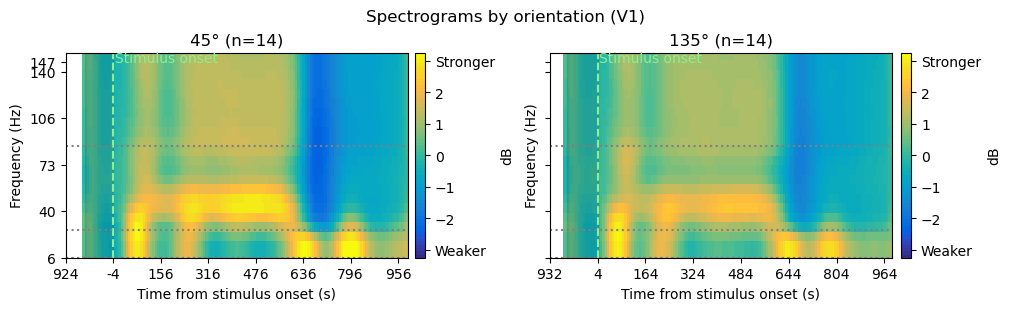

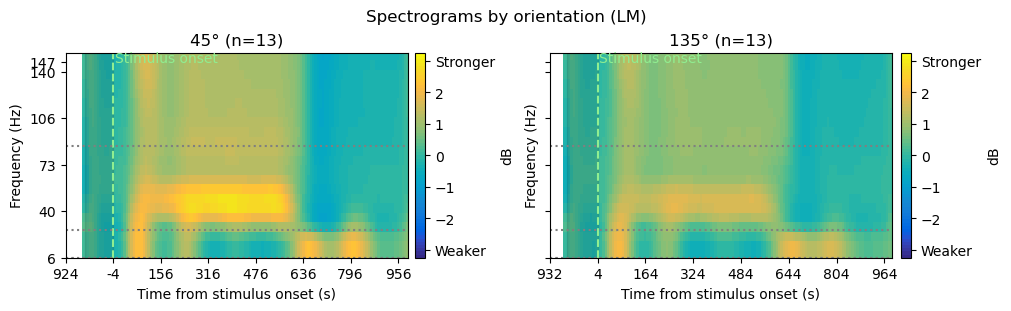

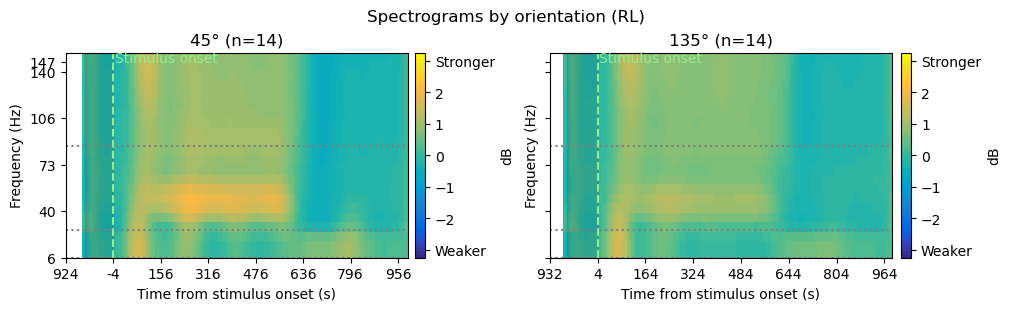

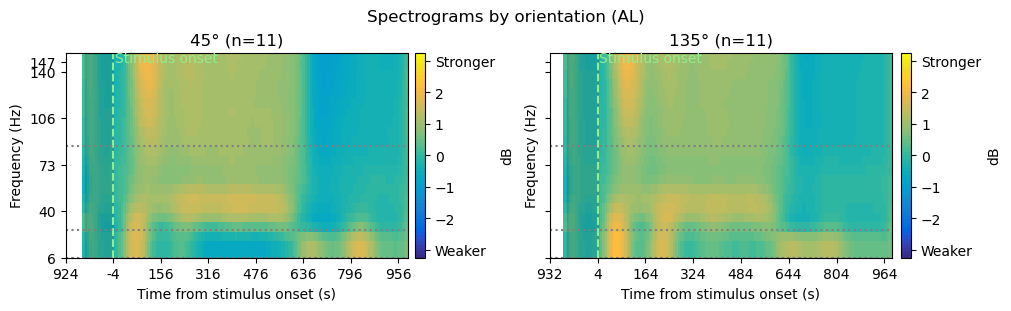

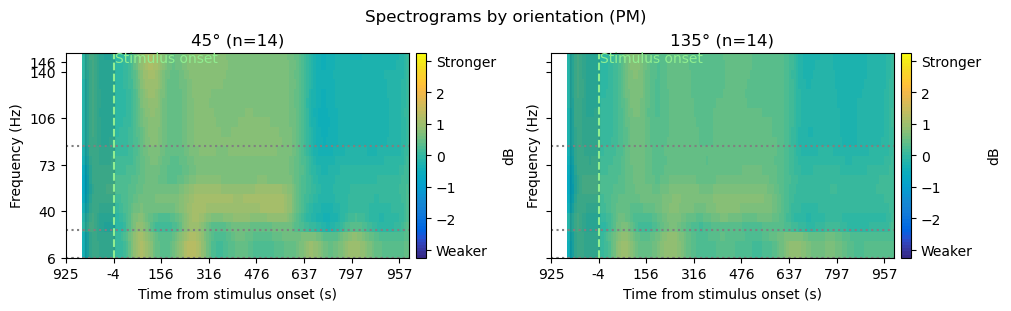

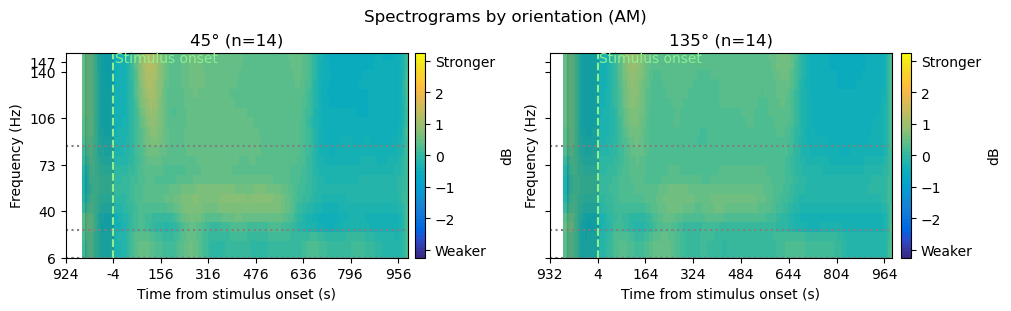

In [14]:
for area in anatomical_areas:
    if any(area not in grand[deg] for deg in ORIENTATIONS):
        continue
    fig, axes = plt.subplots(nrows=1, ncols=len(ORIENTATIONS), figsize=(5 * len(ORIENTATIONS), 3),
                             sharey=True, layout="constrained")
    fig.suptitle("Spectrograms by orientation (%s)" % AREA_TITLES[area])
    for ax, deg in zip(np.atleast_1d(axes), ORIENTATIONS):
        tfr = grand[deg][area].baseline(PRESTIM_BASELINE[0], PRESTIM_BASELINE[1], decibels=True)
        tfr.plot(ax=ax, fig=fig, title="%s (n=%d)" % (ORIENTATION_TITLES[deg], counts[deg][area]),
                 vmin=VMIN, vmax=VMAX, baseline=baseline_mag, cbar_ends=("Stronger", "Weaker"),
                 tlabel="Time from stimulus onset (s)", **EVENTS)
    fig.savefig("%s_orientation_spectrograms.svg" % AREA_TITLES[area])
    fig.savefig("%s_orientation_spectrograms.png" % AREA_TITLES[area])
    plt.show()
    plt.close(fig)